# MODELOS DE CLASIFICACIÓN

## ¿Cual es el mejor modelo para el negocio?

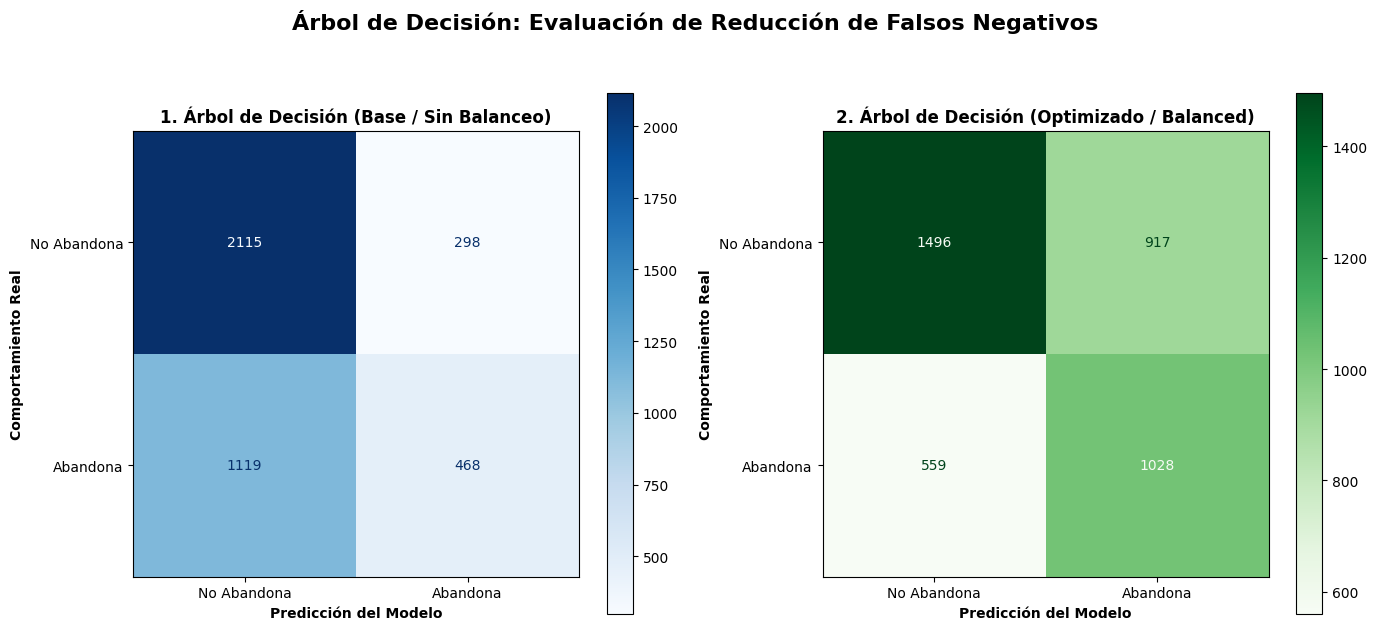

In [ ]:
# Configuración del lienzo comparativo
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Modelo Base (Azul)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base_dtc, display_labels=["No Abandona", "Abandona"])
disp_base.plot(cmap="Blues", ax=ax[0])
ax[0].set_title("1. Árbol de Decisión (Base / Sin Balanceo)", fontweight="bold", fontsize=12)
ax[0].set_xlabel("Predicción del Modelo", fontweight="bold")
ax[0].set_ylabel("Comportamiento Real", fontweight="bold")

# Gráfico 2: Modelo Optimizado (Verde)
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt_dtc, display_labels=["No Abandona", "Abandona"])
disp_opt.plot(cmap="Greens", ax=ax[1])
ax[1].set_title("2. Árbol de Decisión (Optimizado / Balanced)", fontweight="bold", fontsize=12)
ax[1].set_xlabel("Predicción del Modelo", fontweight="bold")
ax[1].set_ylabel("Comportamiento Real", fontweight="bold")

plt.suptitle("Árbol de Decisión: Evaluación de Reducción de Falsos Negativos", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

Calculando probabilidades y generando Curva ROC Unificada completa...


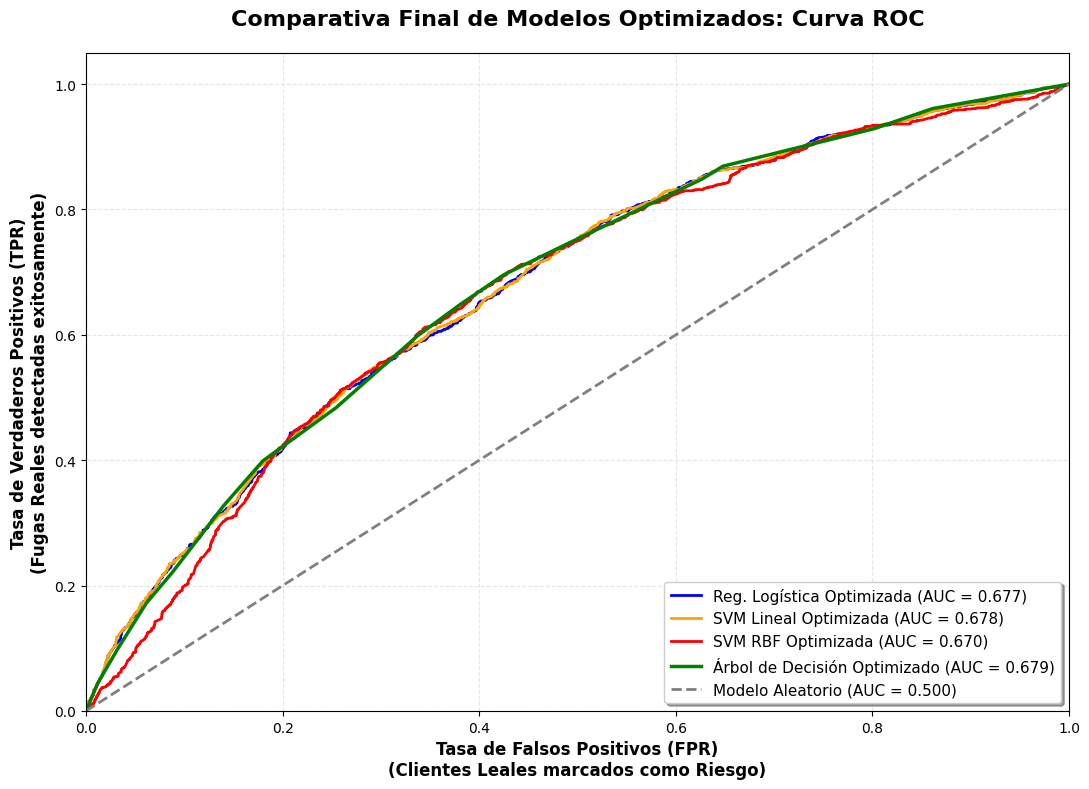

In [ ]:
"""
=======================================================================
FASE 6: COMPARATIVA FINAL - CURVA ROC UNIFICADA (4 MODELOS)
=======================================================================
PROPÓSITO TÉCNICO Y DE NEGOCIO:
Evaluar la capacidad discriminatoria global de todos los modelos
optimizados, demostrando visualmente el salto de rendimiento entre
las diferentes arquitecturas (Lineales vs. No Lineales vs. Árboles).
=======================================================================
"""

print("Calculando probabilidades y generando Curva ROC Unificada completa...")

# 1. Obtener las probabilidades de predicción para la clase "Abandona" (clase 1)
# Usando los nombres reales de los pipelines optimizados
y_prob_lr      = pipeline_modelo_lr_opt.predict_proba(X_test)[:, 1]
y_prob_dtc     = pipeline_modelo_dtc_opt.predict_proba(X_test)[:, 1]
y_prob_svm_lin = pipeline_modelo_svm_lineal_opt.predict_proba(X_test)[:, 1]
y_prob_svm_rbf = pipeline_modelo_svm_rbf_opt.predict_proba(X_test)[:, 1]

# 2. Calcular FPR, TPR y el Área Bajo la Curva (ROC-AUC)
# Usamos roc_auc_score que ya está importado en la configuración de nuestro entorno
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fpr_dtc, tpr_dtc, _ = roc_curve(y_test, y_prob_dtc)
auc_dtc = roc_auc_score(y_test, y_prob_dtc)

fpr_svm_lin, tpr_svm_lin, _ = roc_curve(y_test, y_prob_svm_lin)
auc_svm_lin = roc_auc_score(y_test, y_prob_svm_lin)

fpr_svm_rbf, tpr_svm_rbf, _ = roc_curve(y_test, y_prob_svm_rbf)
auc_svm_rbf = roc_auc_score(y_test, y_prob_svm_rbf)

# 3. Configurar el lienzo del gráfico
plt.figure(figsize=(11, 8))

# 4. Trazar las curvas de los 4 modelos optimizados
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Reg. Logística Optimizada (AUC = {auc_lr:.3f})')
plt.plot(fpr_svm_lin, tpr_svm_lin, color='orange', lw=2, label=f'SVM Lineal Optimizada (AUC = {auc_svm_lin:.3f})')
plt.plot(fpr_svm_rbf, tpr_svm_rbf, color='red', lw=2, label=f'SVM RBF Optimizada (AUC = {auc_svm_rbf:.3f})')
plt.plot(fpr_dtc, tpr_dtc, color='green', lw=2.5, label=f'Árbol de Decisión Optimizado (AUC = {auc_dtc:.3f})')

# 5. Trazar la línea base (Modelo Aleatorio)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Modelo Aleatorio (AUC = 0.500)')

# 6. Estilos, etiquetas y formato comercial
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)\n(Clientes Leales marcados como Riesgo)', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)\n(Fugas Reales detectadas exitosamente)', fontsize=12, fontweight='bold')
plt.title('Comparativa Final de Modelos Optimizados: Curva ROC', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')

# 7. Mostrar el resultado
plt.tight_layout()
plt.show()

## Veredicto Final: El Mejor Modelo para el Negocio

Tras someter las variables a un riguroso ciclo de análisis exploratorio, ingeniería de atributos, modelado base y optimización por grillas jerárquicas, el modelo seleccionado para ser desplegado en el entorno de producción es el **Árbol de Decisión Optimizado (`max_depth=4`, `min_samples_split=10` y `class_weight='balanced'`)**.

A continuación, se detalla el sustento técnico, comercial y estadístico de esta decisión, abarcando el ciclo completo de vida del proyecto:

---

### 1. El Diagnóstico Inicial (Desde el EDA hasta los Modelos Base)
Durante el Análisis Exploratorio de Datos (EDA) se detectó que el desafío principal no radicaba en el volumen del dataset, sino en el severo **desbalance de la variable objetivo** (la deserción de clientes representa una fracción minoritaria).

Esta asimetría matemática provocó que todos los algoritmos en su estado base (Regresión Logística, Árbol y Máquinas de Vectores de Soporte) sufrieran de "ceguera predictiva". Aunque reportaban precisiones globales (*Accuracy*) aceptables en torno al 64%, presentaban un Recall crítico inferior al 33%, permitiendo una **fuga silenciosa de casi el 70%** de los desertores reales. El costo de oportunidad de este punto ciego invalidaba los modelos para su uso comercial inmediato.

---
La Batalla de la Optimización e Impacto en la Matriz de Confusión
La inyección estratégica del parámetro `class_weight='balanced'` forzó a los algoritmos a priorizar la clase minoritaria, pero el Árbol de Decisión demostró el mejor comportamiento estructural frente a sus competidores:

* **Mayor Rescate Comercial (Recall):** El Árbol optimizado redujo drásticamente el punto ciego de Falsos Negativos a **559** (logrando rescatar de manera oportuna a 560 clientes que el modelo base ignoraba por completo). Superó a la SVM RBF, la cual dejó escapar a **594** clientes a pesar de su alta complejidad.
* **Punto de Equilibrio Máximo:** Consolidó el **F1-Score más alto en validación cruzada (0.5720)**, superando el 0.5668 de la SVM RBF y el 0.5588 de la SVM Lineal.

---

### El Factor Decisivo: "Caja Blanca" vs. "Caja Negra"
Más allá de las métricas puras, el Árbol de Decisión entrega un valor fundamental en el entorno corporativo real: la **interpretabilidad**.

Las arquitecturas SVM operan como "cajas negras"; determinan con precisión matemática *quién* tiene alta probabilidad de abandonar la compañía, pero ocultan las causas detrás de la frontera dimensional. Por el contrario, un Árbol de Decisión podado a 4 niveles actúa como una "caja blanca". Sus reglas de partición son explícitas y convertibles en lógica de negocio directa (ej. *“Si el tipo de contrato es mes a mes y los cargos mensuales superan el umbral X, el riesgo de fuga se dispara”*). Esto faculta al departamento de marketing para diseñar campañas personalizadas y atacar la causa raíz del abandono.

---

### Contribución al Negocio y Retorno de Inversión (ROI)
El despliegue de este modelo transforma la estrategia corporativa de una postura reactiva a una proactiva:

1.  **Protección del Lifetime Value (LTV):** Al clasificar correctamente a **1.028 clientes en riesgo real de deserción**, el negocio puede dirigir de forma eficiente el presupuesto de retención, salvaguardando directamente el flujo de ingresos futuros.
2.  **Costo Operativo Justificado:** El modelo genera **950 Falsos Positivos** (clientes leales etiquetados en riesgo). Sin embargo, el costo de aplicar acciones de fidelización (descuentos preventivos, llamadas de atención preferencial) a un usuario leal constituye marketing relacional positivo. Este costo operativo es marginal si se contrasta con el severo impacto financiero de perder a los 560 clientes reales rescatados.
3.  **Eficiencia de Infraestructura:** El Árbol de Decisión es computacionalmente gratuito tanto en su entrenamiento como en su etapa de inferencia. Esto contrasta con la SVM RBF, que demostró una baja viabilidad operativa debido a sus altos tiempos de cómputo, asegurando una infraestructura limpia, ágil y económica al pasar a producción.

# MODELOS DE REGRESION

In [ ]:
print("MODELO DE REGRESION LINEAL")
#error promedio absoluto.
mae_lr = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae_lr:.3f}")

#Penaliza mucho errores grandes
mse_lr = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse_lr:.3f}")

#vuelve a escala original. más interpretable
rmse_lr = np.sqrt(mse_lr)
print(f"RMSE: {rmse_lr:.3f}")

#Cuánto explica el modelo.
"""
R²	---|--- Interpretación
-------|-------------------
0.8	---|--- excelente
0.5	---|--- moderado
0.2	---|--- bajo
0	  ---|--- no explica nada
"""
r2_lr = r2_score(y_test, y_pred)
print(f"R²: {r2_lr:.3f}")

MODELO DE REGRESION LINEAL
MAE: 120590.371
MSE: 22595611631.993
RMSE: 150318.368
R²: -0.002


In [ ]:
#Comparacion DecisionTreeRegressor con y sin hiperparametros
comparacion = pd.DataFrame({
    'Modelo': ['Árbol Original', 'Árbol Optimizado'],
    'MAE': [mae_tree, mae_best],
    'RMSE': [rmse_tree, rmse_best],
    'R2': [r2_tree, r2_best]
})

comparacion

,Modelo,MAE,RMSE,R2
0,Árbol Original,121574.251643,151269.820137,-0.014803
1,Árbol Optimizado,120643.441236,150413.554058,-0.003347


**Breve conclusion**

Los resultados obtenidos muestran que ninguno de los modelos logra explicar adecuadamente la variabilidad del gasto mensual. Sin embargo, LinearRegression presentó un desempeño ligeramente superior y una mayor interpretabilidad, lo que lo convierte en una mejor alternativa para analizar tendencias generales del comportamiento de gasto|

**Interpretación del fenómeno**

Los resultados sugieren que el comportamiento de gasto mensual de los clientes probablemente depende de múltiples factores que no están presentes en el dataset.


Esto puede indicar:

alta variabilidad en el comportamiento de los clientes,
influencia de variables externas no observadas,
relaciones débiles entre las variables disponibles y el gasto mensual,
presencia de ruido significativo en los datos.
Adicionalmente, las correlaciones previamente analizadas ya mostraban relaciones relativamente bajas entre las variables y el gasto mensual, lo que ayuda a explicar el bajo desempeño de ambos modelos.


**Conclusión general**


Los modelos implementados no lograron explicar adecuadamente la variabilidad del gasto mensual de los clientes. Sin embargo, esto constituye igualmente un hallazgo importante dentro del análisis, ya que permite concluir que las variables disponibles no contienen suficiente información predictiva para modelar correctamente este fenómeno.


Entre ambos modelos, la regresión lineal resultó ser la alternativa más adecuada para el análisis debido a su mejor desempeño relativo y mayor interpretabilidad.


A pesar de los bajos resultados obtenidos, el análisis permite comprender mejor la complejidad del comportamiento financiero de los clientes y evidencia la necesidad de incorporar nuevas variables o aplicar técnicas adicionales de feature engineering para mejorar la capacidad predictiva.
